# MFE 230X Final Project, Part 1: Speed

Based on Scholtus and van Dijk (2012), *High-Frequency Technical Trading: The Importance of Speed*, and on the instructions of Discussion Session 06.

| Choice | Value |
|---|---|
| Liquid equity | AAPL (Nasdaq) |
| Less liquid equity | GPRO (Nasdaq) |
| FX pair | EUR/USD |
| Period | September 2019, 20 trading days (3 to 30 September) |
| Signals from the paper | Moving average (MA), on-balance volume (OBV) |
| Own signal | Persistent best-quote imbalance (IMB) |
| Execution delays | 0 ms, 100 ms, 1 second |
| Book | $1,000,000 |

3 assets x 3 signals x 3 delays = **27 profit-and-loss reports** (section 3).

**Trading procedure.**

- A signal in {-1, 0, +1} is built every 60 seconds from the information available at the interval change.
- The order it implies is executed `delay` later against the best quote prevailing at that moment: buys pay the ask, sells receive the bid. The bid-ask spread is the only transaction cost.
- Signals are acted upon from 09:40 to 15:50 New York time only; the book is closed every day at the 15:50:00 price.
- Every trade is for the number of units worth $1,000,000 on the asset's first day (4,850 AAPL shares, 263,505 GPRO shares, EUR 913,013).
- The total return of a strategy is the sum of the simple percentage returns of its round trips (paper eq. 1 and 2), not compounded. The dollar P&L is the same sum valued on the fixed number of units.

**Main results.**

1. All 27 strategies lose money once the spread is paid, from -0.19% (EUR/USD, MA) to -109% (GPRO, IMB). On GPRO the three signals earn money at the mid, and the 22.5 bps spread takes it all back.
2. The cost of delay is small next to the spread. Averaged over the nine asset/signal pairs it is +0.02% at 100 ms and -0.12% at 1 second, and it is negative at every delay from 200 ms.
3. The less liquid stock is hit hardest at 1 second: -0.72% for GPRO IMB and -0.62% for GPRO MA, against -0.27% for AAPL MA and +0.01% for EUR/USD MA.
4. As in the paper, delay hurts profitable rules and helps losing ones: on days when a rule makes money, a 1 second delay lowers its return on all three assets (-1.9% AAPL, -1.9% GPRO, -17.5% EUR/USD).
5. Tick frequency sets how often a delayed order meets a different quote (62% of the time after 1 second on AAPL, 55% on EUR/USD, 1% on GPRO); tick size relative to price sets how much each miss costs (22 bps on GPRO). Sensitivity to delay is the product of the two.

All the logic lives in `src/speed.py`; this notebook runs it and reports the results.

In [1]:
import sys, warnings
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "src")
import speed

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
OUT = Path("outputs"); FIG = OUT / "figures"; FIG.mkdir(parents=True, exist_ok=True)

ASSETS = ["AAPL", "GPRO", "EURUSD"]
SIGNALS = ["MA", "OBV", "IMB"]
ASSET_COLOR = {"AAPL": "#2a78d6", "GPRO": "#eb6834", "EURUSD": "#1baf7a"}   # identity
SIGNAL_COLOR = {"MA": "#2a78d6", "OBV": "#eb6834", "IMB": "#1baf7a"}                    # identity
DELAY_COLOR = {0: "#86b6ef", 100: "#2a78d6", 1000: "#0d366b"}                # magnitude: one hue, light to dark
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb", "savefig.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": MUTED, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold", "legend.frameon": False,
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})

In [2]:
%%time
res, micro = speed.run_all(ASSETS)
res.to_csv(OUT / "daily_results_all_rules.csv", index=False)
print(f"{len(res):,} asset / rule / delay / day results;", res.groupby("asset", sort=False).date.nunique().to_dict(), "trading days")

25,200 asset / rule / delay / day results; {'AAPL': 20, 'GPRO': 20, 'EURUSD': 20} trading days
CPU times: user 16.8 s, sys: 1.19 s, total: 17.9 s
Wall time: 18.1 s


## 1. Data, liquidity and tick frequency

- **Equities.** Databento Nasdaq TotalView-ITCH, MBP-1 schema: every trade and every change of the best bid and offer, nanosecond stamps. Session 09:30 to 16:00 New York time (13:30 to 20:00 UTC).
- **EUR/USD.** Dukascopy tick data: every change of the best bid/ask with the quoted sizes, millisecond stamps (`src/download_fx.py`). It is evaluated over the same 13:30 to 20:00 UTC window and the same 20 days, so the three assets face the same clock and the same number of signals.

Limits of the data:

1. MBP-1 only shows the top of the book. A $1,000,000 order is far larger than the displayed size at the best quote (about 225 AAPL shares, roughly $49,000), so the P&L assumes the whole order fills at the best quote. The paper computes a price-impact price by walking the book; that needs depth data we do not have here.
2. Spot FX has no public trade tape. For EUR/USD the volume input of OBV is tick volume: one unit for each quote that moves the mid.
3. Dukascopy is one venue's feed, so its tick frequency understates the whole EUR/USD market.

In [3]:
liq = micro.groupby("asset", sort=False).mean(numeric_only=True)
table1 = pd.DataFrame({
    "Mid price": liq.mid,
    "Quoted spread (bps)": liq.spread_bps,
    "Quoted spread (price units)": liq.spread_ticks,
    "Depth at best (units)": liq.depth,
    "BBO updates per second": liq.bbo_updates_per_s,
    "Quote price changes per second": liq.quote_moves_per_s,
    "Trades per second": liq.trades_per_s,
    "1-minute volatility (bps)": liq.vol_1min_bps,
    "P(quote changes within 100 ms)": liq.p_quote_change_100ms,
    "P(quote changes within 1 s)": liq.p_quote_change_1000ms,
    "Mean |mid move| after 100 ms (bps)": liq.abs_mid_move_100ms_bps,
    "Mean |mid move| after 1 s (bps)": liq.abs_mid_move_1000ms_bps,
}).T[ASSETS]
table1.loc["Trades per second", "EURUSD"] = np.nan   # no FX trade tape: the OBV input there is tick volume
table1.to_csv(OUT / "table1_liquidity_tick_frequency.csv")
table1.style.format("{:,.4f}", na_rep="n/a")

asset,AAPL,GPRO,EURUSD
Mid price,217.8983,4.5095,1.1011
Quoted spread (bps),0.7335,22.5184,0.2703
Quoted spread (price units),0.0160,0.0101,0.0000
Depth at best (units),225.3725,"4,944.7814",1.6738
BBO updates per second,40.0641,1.7673,1.4444
Quote price changes per second,8.7970,0.0399,1.2063
Trades per second,3.4544,0.1148,n/a
1-minute volatility (bps),5.3174,16.9705,1.1432
P(quote changes within 100 ms),0.2555,0.0023,0.1496
P(quote changes within 1 s),0.6218,0.0113,0.5503


**Reading the table.** The three assets differ on two separate dimensions.

- *Cost of trading.* EUR/USD is the cheapest (0.27 bps quoted spread), AAPL close behind (0.73 bps), GPRO about 30 times more expensive than AAPL (22.5 bps). GPRO trades near $4.50, so the one-cent minimum tick alone is 22 bps of the price: its spread is pinned at one tick.
- *Tick frequency.* AAPL's best quote changes price 8.8 times per second, EUR/USD 1.2 times, GPRO once every 25 seconds. As a result the quote a delayed order meets differs from the one the signal saw 62% of the time after 1 second on AAPL, 55% on EUR/USD and 1.1% on GPRO.

## 2. The three signals

Inputs are sampled at each one-minute interval change $t$: the mid quote $m_t$, the on-balance volume $obv_t$ and the imbalance $I_t$. With $ma_t(n, x)$ the average of the last $n$ values of $x$:

**MA (paper eq. 3).** Long if $ma_t(s,m) > (1+b)\,ma_t(l,m)$, short if $ma_t(s,m) < (1-b)\,ma_t(l,m)$, flat otherwise. Baseline $s=5$, $l=30$, $b=0.0005$ (5 bps, the smallest non-zero band in the paper's grid, so that the rule also trades on EUR/USD).

**OBV (paper eq. 6).** $obv_t$ is the running sum since the open of trade volume signed by the tick rule (+ on an uptick, - on a downtick; auction crosses excluded). Long if $ma_t(s,obv) > ma_t(l,obv) + band$, short if $ma_t(s,obv) < ma_t(l,obv) - band$. The paper's band is proportional to the level; because OBV restarts at zero every day and changes sign, the band here is $b$ times the average one-minute volume over the long window. Baseline $s=5$, $l=30$, $b=0.5$.

**IMB (own signal): persistent best-quote imbalance.** At every instant the queue imbalance is $(q^{bid}-q^{ask})/(q^{bid}+q^{ask})$ with $q$ the size at the best bid and ask. $I_t$ is its time-weighted average over the minute ending at $t$. Long if $I > \theta$ in each of the last $k$ minutes, short if $I < -\theta$ in each of them, flat otherwise. Baseline $k=2$, $\theta=0.3$. The idea: a queue that stays heavier on the bid for whole minutes signals buying pressure that has not yet moved the price; requiring persistence filters the flickering that dominates instantaneous imbalance.

Lookbacks and bandwidths come from the paper's 60-second settings (Appendix A: $s \in \{2, 5, 10, \dots\}$, $l \in \{10, \dots, 60\}$, $b \in \{0.0005, 0.001, 0.0015, \dots\}$ for MA). The same parameters are used for the three assets and were not tuned to improve the P&L. For the Figure 6 analysis each family is widened to 9 parameter sets (27 rules per asset), listed in `speed.UNIVERSE`.

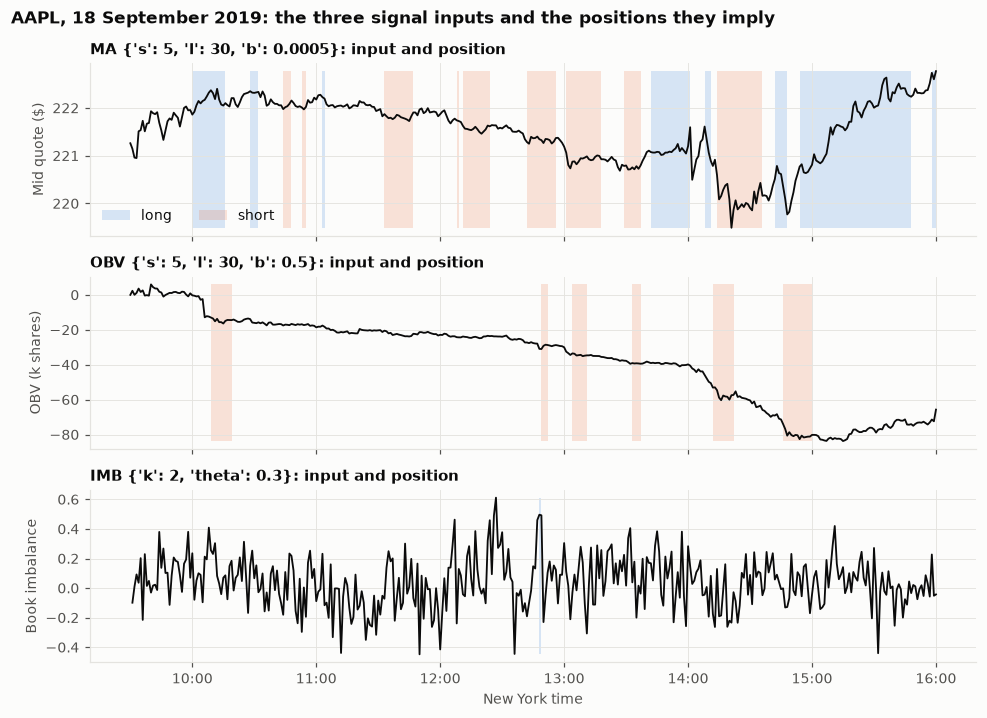

In [4]:
day = speed.load_equity_day("20190918")["AAPL"]      # FOMC day
f = speed.features(day)
t = pd.to_datetime(f["grid"]).tz_localize("UTC").tz_convert("America/New_York").tz_localize(None)
fig, axes = plt.subplots(3, 1, figsize=(9, 6.6), sharex=True)
panels = [("MA", f["mid"], "Mid quote ($)"), ("OBV", f["obv"] / 1e3, "OBV (k shares)"),
          ("IMB", f["imb"], "Book imbalance")]
for ax, (name, y, lab) in zip(axes, panels):
    fn, prm = speed.BASELINE[name]
    sig = fn(f, **prm)
    ax.plot(t, y, color=INK, lw=1.2)
    lo, hi = np.nanmin(y), np.nanmax(y)
    ax.fill_between(t, lo, hi, where=sig == 1, color="#2a78d6", alpha=0.18, lw=0, step="post", label="long")
    ax.fill_between(t, lo, hi, where=sig == -1, color="#eb6834", alpha=0.18, lw=0, step="post", label="short")
    ax.set_title(f"{name} {prm}: input and position", loc="left"); ax.set_ylabel(lab)
axes[0].legend(loc="lower left", ncol=2)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M")); axes[-1].set_xlabel("New York time")
fig.suptitle("AAPL, 18 September 2019: the three signal inputs and the positions they imply", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "01_signals_example_day.png"); plt.show()

## 3. The 27 profit-and-loss reports

One line per asset / signal / delay.

- *P&L* and *Final book* are in dollars for the fixed number of units.
- *Total return* is the sum of the simple round-trip returns.
- *P&L at mid* values the same trades at the mid quote, so *Spread paid* = P&L at mid - P&L is what crossing the spread cost.

In [5]:
rep = speed.pnl_report(res)
rep.to_csv(OUT / "table2_pnl_reports_27.csv", index=False)
print("Units traded per signal ($1,000,000 at the first day's 09:40 mid):",
      {a: round(u, 1) for a, u in micro.groupby("asset", sort=False).units.first().items()})
cols = {"pnl": "P&L ($)", "final_book": "Final book ($)", "total_return_pct": "Total return (%)",
        "pnl_mid": "P&L at mid ($)", "spread_paid": "Spread paid ($)", "round_trips": "Round trips",
        "bps_per_trip": "Net bps / trip", "win_rate_pct": "Win rate (%)",
        "best_day": "Best day ($)", "worst_day": "Worst day ($)", "daily_std": "Daily std ($)"}
show = rep.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", **cols})
show = show.set_index(["Asset", "Signal", "Delay (ms)"])[list(cols.values())]
print(len(show), "profit-and-loss reports")
show.style.format("{:,.0f}").format("{:,.2f}", subset=["Total return (%)", "Net bps / trip", "Win rate (%)"])

Units traded per signal ($1,000,000 at the first day's 09:40 mid): {'AAPL': 4849.9, 'GPRO': 263504.6, 'EURUSD': 913012.7}
27 profit-and-loss reports


In [6]:
tot = rep.pivot_table(index="delay_ms", columns=["asset", "family"], values="total_return_pct", sort=False)
tot.index = tot.index / 1000; tot.index.name = "Delay (s)"
tot.to_csv(OUT / "table2b_total_return_by_delay.csv")
print("Total return (%) by delay")
tot.style.format("{:,.3f}")

Total return (%) by delay


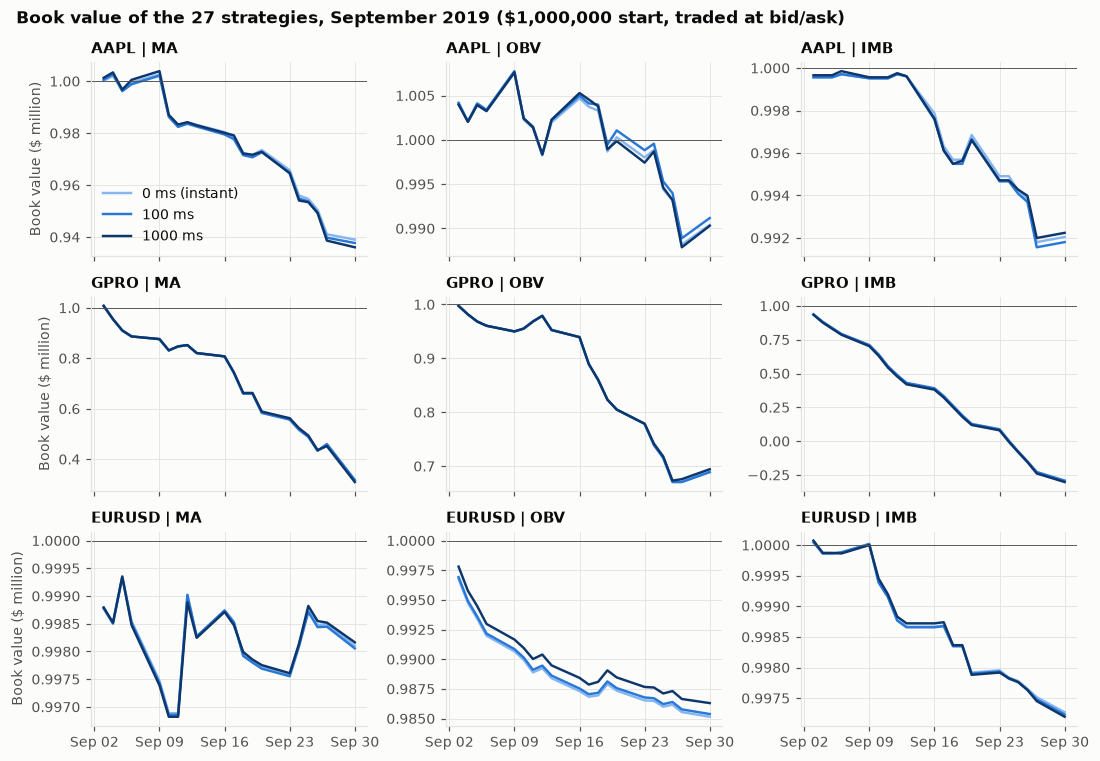

In [7]:
b = res[(res.kind == "baseline") & res.delay_ms.isin(speed.DELAYS_MS)]
fig, axes = plt.subplots(3, 3, figsize=(10, 7), sharex=True)
for i, a in enumerate(ASSETS):
    for j, s in enumerate(SIGNALS):
        ax = axes[i, j]
        for d in speed.DELAYS_MS:
            x = b[(b.asset == a) & (b.family == s) & (b.delay_ms == d)].sort_values("date")
            ax.plot(x.date, speed.BOOK / 1e6 + x.pnl.cumsum() / 1e6, color=DELAY_COLOR[d], lw=1.6,
                    label=f"{d} ms" if d else "0 ms (instant)")
        ax.axhline(1, color=MUTED, lw=0.6)
        ax.set_title(f"{a} | {s}", loc="left")
        if j == 0: ax.set_ylabel("Book value ($ million)")
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
axes[0, 0].legend(loc="lower left")
fig.suptitle("Book value of the 27 strategies, September 2019 ($1,000,000 start, traded at bid/ask)", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "02_book_value_27_strategies.png"); plt.show()

### Holding times

Number of long and short positions over the month and their average length, with instantaneous execution.

In [8]:
hold = speed.holding_report(res)
hold.to_csv(OUT / "table2c_holding_periods.csv")
hold.T.style.format("{:,.2f}")

**What the reports show.**

- **Every strategy loses money net of the spread.** Total returns range from -0.19% (EUR/USD, MA, 56 round trips) to -109% (GPRO, IMB, 618 round trips). A book below zero is possible because the same number of units is traded on every signal without compounding: 618 round trips at about 18 bps each cost more than the book.
- **On GPRO the loss is the spread.** Valued at the mid, the three GPRO strategies make money (+$108,037 for MA, +$84,321 for OBV, +$339,921 for IMB). The spread paid is $0.4 to 1.6 million. The signals predict the direction of the next move, but not by the 22.5 bps a round trip costs.
- **On AAPL the signal itself loses.** AAPL MA loses $37,878 at the mid out of $60,963 in total: a trend rule on one-minute mids buys after the rise and the price partly reverts. The spread is a secondary cost there.
- **Holding times.** MA positions last 9 to 20 minutes on average, OBV positions about 10 minutes, IMB positions 1 to 4 minutes. MA trades about 300 times on each stock and 56 times on EUR/USD, whose one-minute volatility (1.1 bps) rarely carries the short average 5 bps away from the long one. IMB trades far more on GPRO (618 round trips) than on AAPL (42) or EUR/USD (53): GPRO's queues are large and persistently one-sided.
- **The delay lines are almost on top of each other.** Within each panel the three delays differ by far less than the strategy loses. Section 4 measures that difference.

## 4. Cost of delay

Cost of delay = total return with the delay - total return with instantaneous execution, for the same signal, in percentage points. **Negative means the delay hurts.** The Wilcoxon signed-rank test is run on the 20 daily differences (not reported when fewer than 6 days differ). The figure extends the two required delays to the range 0 to 1,000 ms.

In [9]:
cod = speed.cost_of_delay(res)
cod.to_csv(OUT / "table3_cost_of_delay_baseline.csv", index=False)
cod.rename(columns={"asset": "Asset", "family": "Signal", "delay_ms": "Delay (ms)", "return_0ms_pct": "Return 0 ms (%)",
                    "return_delayed_pct": "Return delayed (%)", "cost_pct": "Cost of delay (%)", "cost_usd": "Cost of delay ($)",
                    "cost_bps_per_trip": "Cost (bps / trip)", "days_worse": "Days worse", "days_better": "Days better",
                    "wilcoxon_p": "Wilcoxon p"}
           ).set_index(["Asset", "Signal", "Delay (ms)"]).style.format("{:,.3f}").format(
    "{:,.0f}", subset=["Cost of delay ($)", "Days worse", "Days better"])

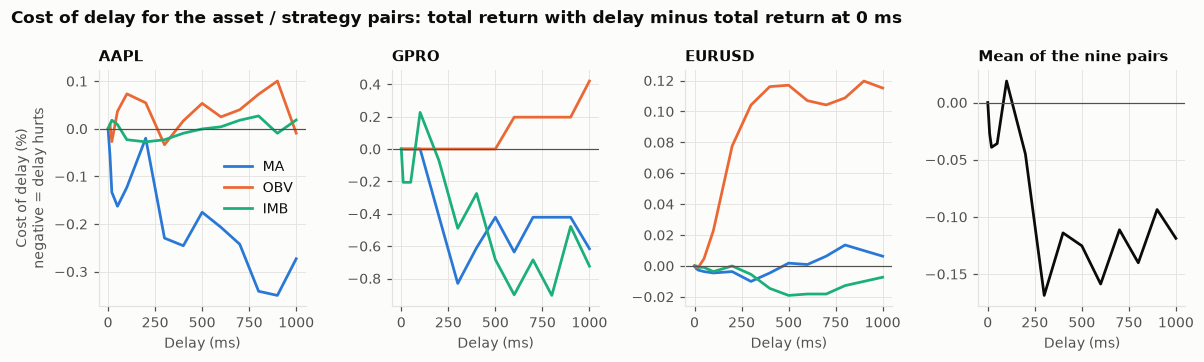

delay_ms,100,1000
AAPL | MA,-0.123,-0.273
AAPL | OBV,0.073,-0.009
AAPL | IMB,-0.023,0.019
GPRO | MA,0.000,-0.616
GPRO | OBV,0.000,0.420
GPRO | IMB,0.226,-0.724
EURUSD | MA,-0.005,0.006
EURUSD | OBV,0.023,0.115
EURUSD | IMB,-0.004,-0.007
Mean,0.019,-0.119


In [10]:
curve = speed.delay_curve(res)
curve.to_csv(OUT / "table3b_cost_of_delay_curve.csv")
fig, axes = plt.subplots(1, 4, figsize=(11, 3.3))
for ax, a in zip(axes, ASSETS):
    for s in SIGNALS:
        ax.plot(curve.index, curve[f"{a} | {s}"], color=SIGNAL_COLOR[s], lw=1.8, label=s)
    ax.set_title(a, loc="left")
axes[3].plot(curve.index, curve["Mean"], color=INK, lw=1.8)
axes[3].set_title("Mean of the nine pairs", loc="left")
for ax in axes:
    ax.axhline(0, color=MUTED, lw=0.8); ax.set_xlabel("Delay (ms)")
axes[0].set_ylabel("Cost of delay (%)\nnegative = delay hurts"); axes[0].legend()
fig.suptitle("Cost of delay for the asset / strategy pairs: total return with delay minus total return at 0 ms", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "03_cost_of_delay_curve.png"); plt.show()
curve.loc[[100, 1000]].T.style.format("{:,.3f}")

**Baseline strategies.**

- **At 100 ms the cost is within 0.23 percentage points for all nine pairs**, with no consistent sign: negative for AAPL MA (-0.12%), positive for GPRO IMB (+0.23%) and AAPL OBV (+0.07%), zero for GPRO MA and OBV, whose execution prices almost never change within 100 ms. The mean over the nine pairs is +0.02%.
- **At 1 second the less liquid stock pays the most.** GPRO IMB loses 0.72 percentage points and GPRO MA 0.62 (-$7,905 each). AAPL MA loses 0.27 (-$2,958) and EUR/USD MA is unchanged (+0.01, +$64). Per round trip: -0.21 bps for GPRO MA, -0.12 bps for GPRO IMB, -0.09 bps for AAPL MA.
- **The OBV strategies gain from delay** at 1 second on GPRO (+0.42%) and EUR/USD (+0.12%). Both lose money at 0 ms, and a late execution of a losing signal gets a slightly better price.
- **The mean curve is negative at every delay from 200 ms**, between -0.05% and -0.17%, and stands at -0.12% at 1 second. This is the shape of the discussion-session example: a small, noisy effect at short delays, a steady cost at longer ones.
- **Statistically, nothing is significant.** With 20 days, no cost in the table is significant at the 5% level. The curves are noisy for the same reason: on GPRO a single one-cent difference on one execution moves the total return by 0.22%.

### Figure 6 of the paper: importance of speed

As in the paper, each day the average return across rules with delay $d$ is compared with the average under instantaneous execution, in percent of the latter, and the daily figures are averaged over the 20 days. Negative means delay lowers performance. The universe is 27 rules per asset (9 parameter sets per family), with the paper's seven delay levels. Rules with a zero return on a day are excluded.

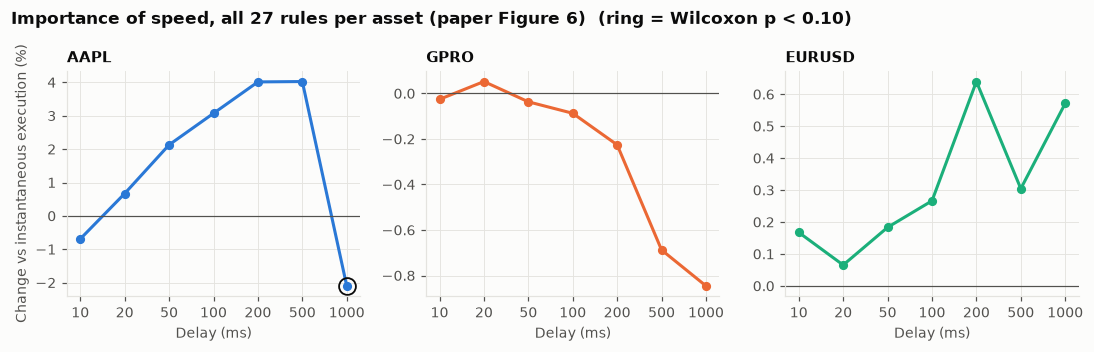

In [11]:
ios = {k: speed.importance_of_speed(res, subset=k) for k in ("all", "positive", "negative")}
pd.concat(ios, names=["strategies"]).reset_index(level=0).to_csv(OUT / "table4_importance_of_speed.csv", index=False)

def fig6(tab, title, fname):
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.2))
    for ax, a in zip(axes, ASSETS):
        x = tab[tab.asset == a]
        pos = np.arange(len(x))
        ax.plot(pos, x.importance_pct, color=ASSET_COLOR[a], marker="o", ms=5)
        sigp = x.wilcoxon_p.to_numpy() < 0.10
        ax.plot(pos[sigp], x.importance_pct.to_numpy()[sigp], ls="", marker="o", ms=11, mfc="none", mec=INK, mew=1.2)
        ax.axhline(0, color=MUTED, lw=0.8)
        ax.set_xticks(pos); ax.set_xticklabels(x.delay_ms); ax.set_xlabel("Delay (ms)")
        ax.set_title(a, loc="left")
    axes[0].set_ylabel("Change vs instantaneous execution (%)")
    fig.suptitle(title + "  (ring = Wilcoxon p < 0.10)", x=0.01, ha="left", fontweight="bold")
    fig.tight_layout(); fig.savefig(FIG / fname); plt.show()

fig6(ios["all"], "Importance of speed, all 27 rules per asset (paper Figure 6)", "04_importance_of_speed_all.png")
ios["all"].query("delay_ms in (100, 1000)").set_index(["asset", "delay_ms"]).style.format("{:,.3f}")

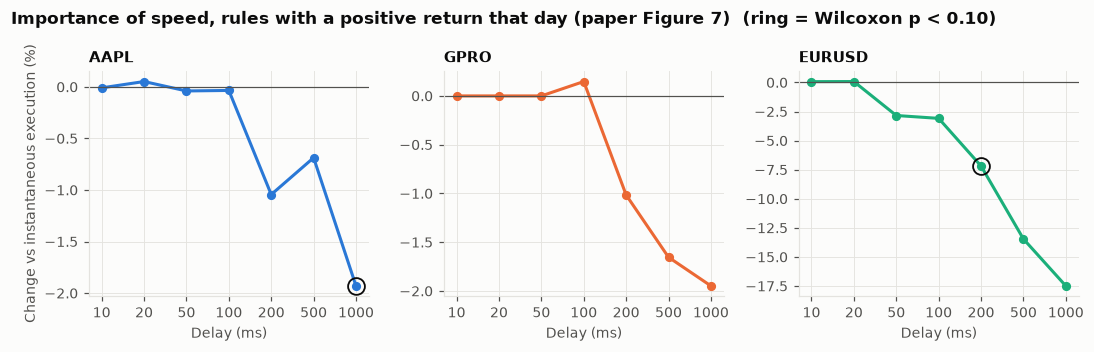

In [12]:
fig6(ios["positive"], "Importance of speed, rules with a positive return that day (paper Figure 7)", "05_importance_of_speed_positive.png")
pd.concat({k: v.query("delay_ms in (100, 1000)").set_index(["asset", "delay_ms"])[["importance_pct", "pooled_pct", "diff_bps_per_day", "n_days", "wilcoxon_p"]]
           for k, v in ios.items()}, axis=1).style.format("{:,.3f}")

**Reading the Figure 6 results.**

- **All rules (first figure).** GPRO declines steadily with delay, from 0 to -0.85% at 1 second. AAPL is positive from 20 to 500 ms (+3.1% at 100 ms) and negative at 1 second (-2.1%, p = 0.10). EUR/USD is slightly positive (+0.3% at 100 ms, +0.6% at 1 second). Only the AAPL 1 second point is significant at 10%. The AAPL average is fragile: it is a mean of daily ratios, and the median (+0.3% at 100 ms, -2.2% at 1 second) and the pooled figure (+0.2%, -4.4%) both show no gain at short delays and a loss at 1 second.
- **Profitable rule-days (second figure).** Restricting each day to the rules that made money with instantaneous execution, a 1 second delay lowers performance on all three assets: -1.9% on AAPL (p = 0.09), -1.9% on GPRO, -17.5% on EUR/USD (median -3.1%). On EUR/USD the loss is already visible at 200 ms (-7.2%, p = 0.09).
- **Losing rule-days.** The effect is weaker or reversed: on EUR/USD a 1 second delay improves losing rules by 3.0% (p = 0.02).

This is the paper's central result: speed matters for strategies that make money, because their edge is a price move that others also trade on, and the first part of that move is lost during the delay. A losing strategy is on the wrong side of that move and benefits from arriving late. The paper finds a significant loss from 200 ms on SPY with 186 days and 27,424 rules; with 20 days and 27 rules our estimates have the same sign but little significance.

## 5. Do signals behave differently across market conditions?

Days are split, asset by asset, into the 10 most and 10 least volatile (one-minute mid-quote volatility). Costs are in bps of the book per rule-day (negative = delay hurts); *abs effect* is the mean absolute change in return from a 1 second delay, per round trip, which measures sensitivity regardless of sign.

In [13]:
u = res[res.kind == "universe"]
wide = u.pivot_table(index=["asset", "family", "params", "date"], columns="delay_ms", values="ret", sort=False)
wide = wide[wide[0] != 0]
trips = u[u.delay_ms == 0].set_index(["asset", "family", "params", "date"]).n_trips.reindex(wide.index)
grp = lambda x: x.groupby(level=["asset", "date"], sort=False)
d = wide.groupby(level=["asset", "date"], sort=False).mean()
daily = pd.DataFrame({"ret0_bps": d[0] * 1e4, "cost100_bps": (d[100] - d[0]) * 1e4, "cost1000_bps": (d[1000] - d[0]) * 1e4,
                      "trips_per_rule": grp(trips).mean(),
                      "abs100_bps": grp((wide[100] - wide[0]).abs()).sum() / grp(trips).sum() * 1e4,
                      "abs1000_bps": grp((wide[1000] - wide[0]).abs()).sum() / grp(trips).sum() * 1e4})
daily = daily.join(micro.set_index(["asset", "date"]))
daily["vol_regime"] = daily.groupby(level="asset", sort=False).vol_1min_bps.transform(lambda x: np.where(x > x.median(), "high vol", "low vol"))
daily.to_csv(OUT / "daily_cost_and_microstructure.csv")
cond = daily.groupby(["asset", "vol_regime"], sort=False).agg(
    days=("ret0_bps", "size"), vol_1min_bps=("vol_1min_bps", "mean"), spread_bps=("spread_bps", "mean"),
    quote_changes_per_s=("quote_moves_per_s", "mean"), ret0_bps_per_day=("ret0_bps", "mean"),
    cost100_bps_per_day=("cost100_bps", "mean"), cost1000_bps_per_day=("cost1000_bps", "mean"),
    abs_effect_1s_bps_per_trip=("abs1000_bps", "mean")).reindex(ASSETS, level=0)
cond.to_csv(OUT / "table5_volatility_regimes.csv")
cond.style.format("{:,.3f}")

In [14]:
fam = speed.importance_of_speed(res, by=("asset", "family")).query("delay_ms in (100, 1000)")
fam.to_csv(OUT / "table6_importance_by_signal_family.csv", index=False)
bysig = wide.assign(c100=(wide[100] - wide[0]) * 1e4, c1000=(wide[1000] - wide[0]) * 1e4,
                    a1000=(wide[1000] - wide[0]).abs() * 1e4, r0=wide[0] * 1e4).groupby(level=["asset", "family"], sort=False)[["r0", "c100", "c1000", "a1000"]].mean()
bysig.columns = ["Return at 0 ms (bps/day)", "Cost 100 ms (bps/day)", "Cost 1 s (bps/day)", "Mean |effect| 1 s (bps/day)"]
bysig.to_csv(OUT / "table6b_cost_by_signal_family_bps.csv")
bysig.style.format("{:,.3f}")

**Performance and volatility.**

- **Delay costs more on volatile days.** A 1 second delay costs 1.8 bps per rule-day on AAPL's volatile days and nothing on quiet days (+0.2); on GPRO 2.6 bps against a small gain (+0.4). On EUR/USD the signed cost is close to zero in both regimes.
- **Sensitivity to delay rises with volatility on all three assets.** The absolute effect of a 1 second delay per round trip is 0.42 bps against 0.32 on AAPL, 0.60 against 0.17 on GPRO, 0.11 against 0.05 on EUR/USD. The quote moves further during the delay when the market is moving faster. The paper finds the opposite ordering for SPY (speed matters more on low-volatility days).
- **Performance itself is worse on volatile days for AAPL** (-23 bps per rule-day against -14): the trend rules trade more and are whipsawed more. GPRO and EUR/USD lose about the same in both regimes.
- **By signal family.** MA is the most delay-sensitive rule on the two stocks (-1.1 bps per day on AAPL, -2.6 on GPRO at 1 second), followed by IMB on GPRO (-2.4). OBV gains from delay on GPRO and EUR/USD. IMB holds positions for 1 to 4 minutes, so a 1 second delay is a larger fraction of its holding period than for MA and OBV (10 to 20 minutes); on AAPL it trades too rarely (42 round trips) to measure the effect.

## 6. Tick frequency and the importance of delay

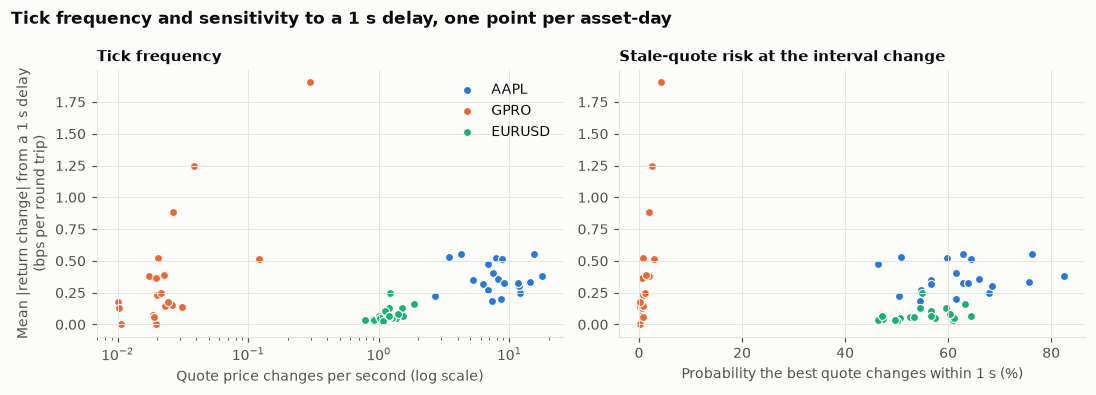

asset,AAPL,GPRO,EURUSD
quote_moves_per_s,8.7970,0.0399,1.2063
p_quote_change_100ms,0.2555,0.0023,0.1496
p_quote_change_1000ms,0.6218,0.0113,0.5503
abs_mid_move_100ms_bps,0.1117,0.0444,0.0122
abs_mid_move_1000ms_bps,0.4804,0.2370,0.0839
spread_bps,0.7335,22.5184,0.2703
abs100_bps,0.1271,0.0736,0.0173
abs1000_bps,0.3691,0.3867,0.0788
cost100_bps,0.0412,-0.1002,0.0205
cost1000_bps,-0.8121,-1.0797,0.1158


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for a in ASSETS:
    x = daily.loc[a]
    axes[0].scatter(x.quote_moves_per_s, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
    axes[1].scatter(x.p_quote_change_1000ms * 100, x.abs1000_bps, s=28, color=ASSET_COLOR[a], edgecolor="#fcfcfb", lw=0.8, label=a)
axes[0].set_xscale("log"); axes[0].set_xlabel("Quote price changes per second (log scale)")
axes[1].set_xlabel("Probability the best quote changes within 1 s (%)")
axes[0].set_ylabel("Mean |return change| from a 1 s delay\n(bps per round trip)")
axes[0].set_title("Tick frequency", loc="left"); axes[1].set_title("Stale-quote risk at the interval change", loc="left")
axes[0].legend()
fig.suptitle("Tick frequency and sensitivity to a 1 s delay, one point per asset-day", x=0.01, ha="left", fontweight="bold")
fig.tight_layout(); fig.savefig(FIG / "06_tick_frequency_vs_delay_sensitivity.png"); plt.show()

tick = daily.groupby(level="asset", sort=False)[["quote_moves_per_s", "p_quote_change_100ms", "p_quote_change_1000ms", "abs_mid_move_100ms_bps",
        "abs_mid_move_1000ms_bps", "spread_bps", "abs100_bps", "abs1000_bps", "cost100_bps", "cost1000_bps"]].mean().reindex(ASSETS)
tick["|mid move| 1 s / half-spread"] = tick.abs_mid_move_1000ms_bps / (tick.spread_bps / 2)
tick.to_csv(OUT / "table7_tick_frequency_and_delay.csv")
tick.T.style.format("{:,.4f}")

**Does tick frequency drive the importance of delay?** Partly, and the table shows why it is not the whole story.

- **Tick frequency sets the probability of a stale quote.** After 100 ms the best quote has changed 26% of the time on AAPL, 15% on EUR/USD and 0.2% on GPRO; after 1 second, 62%, 55% and 1.1%.
- **At short delays the fast book is the exposed one.** At 100 ms the absolute effect per round trip is 0.13 bps on AAPL, 0.07 on GPRO and 0.02 on EUR/USD: only a book that ticks many times per second can move in 100 ms.
- **Tick size relative to price sets the cost of each miss.** When GPRO's quote does move it moves by a full cent, 22 bps. AAPL's cent is 0.5 bp and an EUR/USD pip fraction is under 0.1 bp. So at 1 second GPRO, the slowest book by a factor of 200, is as sensitive per round trip as AAPL (0.39 against 0.37 bps), and EUR/USD is far behind (0.08 bps) despite ticking 30 times faster than GPRO.
- **Within an asset, busier days are more delay-sensitive** on GPRO and EUR/USD (correlation of daily sensitivity with quote changes per second: 0.78 and 0.46). On AAPL there is no such relation (-0.01): the quote changes within a second most of the time on every day.
- **What matters for a strategy is the expected move against the half-spread.** After 1 second the mid has moved on average 1.3 half-spreads on AAPL, 0.6 on EUR/USD and 0.02 on GPRO.

**How we would factor this into a trading strategy.**

1. *Budget latency per asset in units of expected quote move, not in milliseconds.* The relevant number is P(quote changes during the delay) x size of a tick in bps, compared with the signal's expected edge. On AAPL that requires being well inside 100 ms; on GPRO 100 ms is free and the cost only appears at several hundred milliseconds.
2. *Match the signal's horizon to the achievable latency.* A rule that holds for 10 minutes loses little to a 1 second delay; a rule that holds for 1 to 4 minutes, like IMB, needs proportionally lower latency.
3. *In large-tick, slow books, do not cross the spread.* GPRO's signals have gross value but 22.5 bps per round trip is unaffordable for a taker. The same signals should be expressed with passive orders: queue position then replaces latency as the scarce resource.
4. *Do not pay for speed on a signal that loses.* Delay only costs on the days and rules that make money. Speed is valuable once the signal predicts the next move; otherwise it just delivers the wrong trade sooner.
5. *Scale speed requirements with volatility.* The cost of a 1 second delay is concentrated on volatile days for both stocks; wider bandwidths or standing aside around scheduled events limit the exposure when the infrastructure cannot be faster.

## 7. Limits

- One month and 27 rules per asset: almost no cost-of-delay estimate is statistically different from zero, and single one-tick differences move the GPRO curves.
- Orders are assumed to fill in full at the best quote. A $1,000,000 order would walk the book in AAPL and GPRO, so true costs, and the cost of arriving after others have taken the best level, are understated.
- EUR/USD uses one venue's quotes and tick volume in place of traded volume.
- Nasdaq quotes only: the consolidated best bid and offer may be tighter than the Nasdaq book, especially for GPRO.